# Realness Validation — Blast-on-Brown-Spot Composites

Folders involved:
- `blast_lesion_patches` — 728 source lesion patches (`Blast_0001_lesion.png` ... + `.csv` metadata), no direct ID link to which composite used them.
- `brown_spot` — real base leaf images (path needs confirming, see Section 1).
- `blast_on_brown_spot_cleaned` — 618 final composites (`blast_on_brownspot_BROWNSPOT1_092.jpg`), the synthetic dataset to validate.

**Important limitation:** composite filenames only retain the *base leaf ID*
(e.g. `BROWNSPOT1_092`), not the lesion patch ID that was pasted onto it. So we
cannot deterministically recover "which `Blast_00XX_lesion.png` went into which
composite" from filenames alone (unless a compositing log/manifest CSV exists —
check for one, and tell me if you have it, it would make Section 3 exact instead
of derived).

**Workaround used here:** Section 3 (Boundary Artifact Detection) derives an
approximate paste mask by pixel-diffing each composite against its *matched base
leaf image* (matched via the shared `BROWNSPOT{n}_{num}` ID) — this sidesteps
needing the original lesion patch entirely and is actually a direct read of
"where did pixels change," which is exactly what we want for seam detection.


In [1]:
# ---- SETUP: mount drive & install dependencies ----
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-image opencv-python-headless pandas matplotlib scipy
!pip install -q pyiqa
!pip install -q pytorch-fid
!pip install -q torch torchvision --upgrade -q


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 18.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [2]:
import os, re, glob
import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

DRIVE_ROOT = "/content/drive/MyDrive"
OUTPUT_DIR = os.path.join(DRIVE_ROOT, "realness_validation")
os.makedirs(OUTPUT_DIR, exist_ok=True)


Device: cuda


## 1. Folder Paths & Inventory

Confirmed paths from your Drive. This just lists counts, extensions, and sample
filenames for each folder so the naming pattern of `brown_spot` is visible before
we build the matching logic in Section 2.


In [3]:
LESION_PATCH_DIR = "/content/drive/MyDrive/blast_lesion_patches"
BROWN_SPOT_DIR    = "/content/drive/MyDrive/brown_spot"
SYNTHETIC_DIR      = "/content/drive/MyDrive/blast_on_brown_spot_cleaned"

for label, path in {
    "blast_lesion_patches": LESION_PATCH_DIR,
    "brown_spot": BROWN_SPOT_DIR,
    "blast_on_brown_spot_cleaned": SYNTHETIC_DIR,
}.items():
    print(f"\n[{label}]  path: {path}")
    if not os.path.isdir(path):
        print("  MISSING FOLDER — fix the path above before continuing.")
        continue
    files = sorted([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
    exts = sorted(set(os.path.splitext(f)[1].lower() for f in files))
    print(f"  count: {len(files)}  |  extensions: {exts}")
    print("  sample filenames:")
    for f in files[:10]:
        print("   ", f)



[blast_lesion_patches]  path: /content/drive/MyDrive/blast_lesion_patches
  count: 728  |  extensions: ['.csv', '.png']
  sample filenames:
    Blast_0001_lesion.png
    Blast_0002_lesion.png
    Blast_0003_lesion.png
    Blast_0004_lesion.png
    Blast_0005_lesion.png
    Blast_0006_lesion.png
    Blast_0007_lesion.png
    Blast_0008_lesion.png
    Blast_0009_lesion.png
    Blast_0010_lesion.png

[brown_spot]  path: /content/drive/MyDrive/brown_spot
  count: 1389  |  extensions: ['.jpg']
  sample filenames:
    BROWNSPOT1_019.jpg
    BROWNSPOT1_033.jpg
    BROWNSPOT1_035.jpg
    BROWNSPOT1_036.jpg
    BROWNSPOT1_045.jpg
    BROWNSPOT1_052.jpg
    BROWNSPOT1_063.jpg
    BROWNSPOT1_065.jpg
    BROWNSPOT1_066.jpg
    BROWNSPOT1_073.jpg

[blast_on_brown_spot_cleaned]  path: /content/drive/MyDrive/blast_on_brown_spot_cleaned
  count: 618  |  extensions: ['.jpg']
  sample filenames:
    blast_on_brownspot_BROWNSPOT1_092.jpg
    blast_on_brownspot_BROWNSPOT3_036.jpg
    blast_on_brownspot_B

## 2. ID Matching Dry-Run

Extracts the `BROWNSPOT{n}_{num}` style ID from each composite filename, then
searches `brown_spot` for a filename **containing that same ID as a substring**
(case-insensitive) — this is deliberately loose since we don't know brown_spot's
exact naming convention until the cell above prints it. Reports match counts
**before** running any test. Check the sample output — if matches look wrong
(e.g. matching multiple files, or 0% matched), tell me the actual brown_spot
naming pattern shown above and I'll tighten the regex.


In [4]:
# Composite name format: blast_on_brownspot_BROWNSPOT{n}_{num}.jpg
ID_PATTERN = re.compile(r"BROWNSPOT(\d+)_(\d+)", re.IGNORECASE)

def extract_id_parts(filename):
    m = ID_PATTERN.search(filename)
    if not m:
        return None, None
    return m.group(1), m.group(2)  # e.g. ('1', '092')

synthetic_files = sorted([f for f in os.listdir(SYNTHETIC_DIR) if os.path.isfile(os.path.join(SYNTHETIC_DIR, f))])
brown_spot_files = sorted([f for f in os.listdir(BROWN_SPOT_DIR) if os.path.isfile(os.path.join(BROWN_SPOT_DIR, f))]) if os.path.isdir(BROWN_SPOT_DIR) else []

def find_candidates(group_num, img_num, bs_files):
    """Try progressively looser matches against brown_spot filenames:
    1. exact 'BROWNSPOT{n}_{num}' substring
    2. 'brownspot{n}_{num}' without underscore variants (e.g. BS1_092, brown_spot1_092)
    3. just the numeric id '{num}' as a standalone token (last resort, checked for ambiguity)
    """
    exact_tag = f"brownspot{group_num}_{img_num}".lower()
    exact = [f for f in bs_files if exact_tag in f.lower().replace("_", "").replace("brownspot", "brownspot")]
    exact = [f for f in bs_files if f"{group_num}_{img_num}" in re.sub(r"[^0-9_]", "", f.lower())]
    if exact:
        return exact, "exact_id"

    loose_tag = f"{group_num}_{img_num}"
    loose = [f for f in bs_files if loose_tag in f]
    if loose:
        return loose, "loose_number_match"

    num_only = [f for f in bs_files if re.search(rf"(?<!\d){img_num}(?!\d)", f)]
    if len(num_only) >= 1:
        return num_only, "numeric_only_fallback"

    return [], "no_match"

match_rows = []
for syn_fname in synthetic_files:
    group_num, img_num = extract_id_parts(syn_fname)
    if group_num is None:
        match_rows.append({"synthetic_filename": syn_fname, "extracted_id": None,
                            "matched_base": None, "status": "id_extraction_failed"})
        continue

    syn_id = f"BROWNSPOT{group_num}_{img_num}"
    candidates, method = find_candidates(group_num, img_num, brown_spot_files)

    if len(candidates) == 0:
        match_rows.append({"synthetic_filename": syn_fname, "extracted_id": syn_id,
                            "matched_base": None, "status": "no_match"})
    elif len(candidates) == 1:
        match_rows.append({"synthetic_filename": syn_fname, "extracted_id": syn_id,
                            "matched_base": candidates[0], "status": f"matched_{method}"})
    else:
        match_rows.append({"synthetic_filename": syn_fname, "extracted_id": syn_id,
                            "matched_base": candidates[0], "status": f"ambiguous_{method}_{len(candidates)}"})

df_match = pd.DataFrame(match_rows)
df_match.to_csv(os.path.join(OUTPUT_DIR, "id_matching_dry_run.csv"), index=False)

print(df_match["status"].value_counts())
n_matched = df_match["status"].str.startswith("matched").sum()
print(f"\nMatched (any method): {n_matched} / {len(df_match)}")
print("\nIMPORTANT: if 'ambiguous_*' or 'numeric_only_fallback' counts are high, the match")
print("quality is unreliable — check df_match manually and tighten find_candidates() before")
print("trusting Section 3's results. 'matched_exact_id' rows are the trustworthy ones.")
df_match.head(15)


status
id_extraction_failed    584
matched_exact_id         34
Name: count, dtype: int64

Matched (any method): 34 / 618

IMPORTANT: if 'ambiguous_*' or 'numeric_only_fallback' counts are high, the match
quality is unreliable — check df_match manually and tighten find_candidates() before
trusting Section 3's results. 'matched_exact_id' rows are the trustworthy ones.


,synthetic_filename,extracted_id,matched_base,status
0,blast_on_brownspot_BROWNSPOT1_092.jpg,BROWNSPOT1_092,BROWNSPOT1_092.jpg,matched_exact_id
1,blast_on_brownspot_BROWNSPOT3_036.jpg,BROWNSPOT3_036,BROWNSPOT3_036.jpg,matched_exact_id
2,blast_on_brownspot_BROWNSPOT3_068.jpg,BROWNSPOT3_068,BROWNSPOT3_068.jpg,matched_exact_id
3,blast_on_brownspot_BROWNSPOT3_095.jpg,BROWNSPOT3_095,BROWNSPOT3_095.jpg,matched_exact_id
4,blast_on_brownspot_BROWNSPOT4_020.jpg,BROWNSPOT4_020,BROWNSPOT4_020.jpg,matched_exact_id
5,blast_on_brownspot_BROWNSPOT4_057.jpg,BROWNSPOT4_057,BROWNSPOT4_057.jpg,matched_exact_id
6,blast_on_brownspot_BROWNSPOT4_058.jpg,BROWNSPOT4_058,BROWNSPOT4_058.jpg,matched_exact_id
7,blast_on_brownspot_BROWNSPOT4_075.jpg,BROWNSPOT4_075,BROWNSPOT4_075.jpg,matched_exact_id
8,blast_on_brownspot_BROWNSPOT4_095.jpg,BROWNSPOT4_095,BROWNSPOT4_095.jpg,matched_exact_id
9,blast_on_brownspot_BROWNSPOT4_167.jpg,BROWNSPOT4_167,BROWNSPOT4_167.jpg,matched_exact_id


## 3. Boundary Artifact Detection (diff-derived mask)

For every **matched** pair: resizes the base leaf image to the composite's
resolution if needed, computes the absolute pixel difference, thresholds it
(Otsu) to get an approximate paste mask, then runs the same ring-based seam
scoring as before on that derived mask — checking color/gradient discontinuity
right at the seam vs. just outside it and vs. the interior of the pasted region.


In [5]:
def derive_paste_mask(composite_bgr, base_bgr, min_area_ratio=0.002):
    if base_bgr.shape[:2] != composite_bgr.shape[:2]:
        base_bgr = cv2.resize(base_bgr, (composite_bgr.shape[1], composite_bgr.shape[0]))

    diff = cv2.absdiff(composite_bgr, base_bgr)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    diff_blur = cv2.GaussianBlur(diff_gray, (5, 5), 0)

    _, mask = cv2.threshold(diff_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # clean up: remove tiny noise, keep largest connected component (the pasted lesion)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n_labels <= 1:
        return None
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    area = stats[largest, cv2.CC_STAT_AREA]
    if area < min_area_ratio * composite_bgr.shape[0] * composite_bgr.shape[1]:
        return None
    clean_mask = np.uint8(labels == largest) * 255
    return clean_mask, base_bgr


def compute_boundary_artifact_score(image_bgr, mask, ring_width=5):
    mask_bin = (mask > 127).astype(np.uint8)
    kernel = np.ones((ring_width, ring_width), np.uint8)
    dilated = cv2.dilate(mask_bin, kernel, iterations=1)
    eroded  = cv2.erode(mask_bin, kernel, iterations=1)

    boundary_ring = (dilated - eroded).astype(np.uint8)
    outside_ring  = (cv2.dilate(dilated, kernel, iterations=2) - dilated).astype(np.uint8)
    interior_mask = eroded.astype(np.uint8)

    if boundary_ring.sum() == 0 or interior_mask.sum() == 0:
        return None

    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    grad_mag = np.zeros(gray.shape, dtype=np.float32)
    for c in range(3):
        gx = cv2.Sobel(lab[:, :, c], cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(lab[:, :, c], cv2.CV_32F, 0, 1, ksize=3)
        grad_mag += cv2.magnitude(gx, gy)

    boundary_grad = grad_mag[boundary_ring == 1].mean() if boundary_ring.sum() > 0 else 0
    outside_grad  = grad_mag[outside_ring == 1].mean() if outside_ring.sum() > 0 else 1e-6
    grad_ratio = boundary_grad / (outside_grad + 1e-6)

    lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
    boundary_lap_var = lap[boundary_ring == 1].var() if boundary_ring.sum() > 0 else 0
    interior_lap_var = lap[interior_mask == 1].var() if interior_mask.sum() > 0 else 1e-6
    lap_ratio = boundary_lap_var / (interior_lap_var + 1e-6)

    boundary_color = lab[boundary_ring == 1].mean(axis=0)
    outside_color  = lab[outside_ring == 1].mean(axis=0)
    color_jump = np.linalg.norm(boundary_color - outside_color)

    combined_score = 0.4 * grad_ratio + 0.4 * lap_ratio + 0.2 * (color_jump / 10.0)

    return {
        "grad_ratio": round(float(grad_ratio), 4),
        "lap_ratio": round(float(lap_ratio), 4),
        "color_jump_lab": round(float(color_jump), 4),
        "boundary_artifact_score": round(float(combined_score), 4),
    }


In [6]:
# ---- Run on all matched pairs from Section 2 ----
# Only use exact_id matches by default (most reliable). Switch to
# df_match["status"].str.startswith("matched") if you need more coverage
# and have manually checked the loose/numeric-fallback matches are correct.
matched_pairs = df_match[df_match["status"] == "matched_exact_id"]

results_boundary = []
for _, row in matched_pairs.iterrows():
    syn_path = os.path.join(SYNTHETIC_DIR, row["synthetic_filename"])
    base_path = os.path.join(BROWN_SPOT_DIR, row["matched_base"])

    composite = cv2.imread(syn_path)
    base = cv2.imread(base_path)

    if composite is None or base is None:
        results_boundary.append({"filename": row["synthetic_filename"], "status": "read_error"})
        continue

    derived = derive_paste_mask(composite, base)
    if derived is None:
        results_boundary.append({"filename": row["synthetic_filename"], "status": "mask_derivation_failed"})
        continue
    mask, base_resized = derived

    metrics = compute_boundary_artifact_score(composite, mask)
    if metrics is None:
        results_boundary.append({"filename": row["synthetic_filename"], "status": "degenerate_mask"})
        continue

    r = {"filename": row["synthetic_filename"], "status": "ok"}
    r.update(metrics)
    results_boundary.append(r)

df_boundary = pd.DataFrame(results_boundary)
valid = df_boundary[df_boundary["status"] == "ok"].copy()
if len(valid) > 0:
    threshold = valid["boundary_artifact_score"].quantile(0.90)
    valid["flag_visible_seam"] = valid["boundary_artifact_score"] >= threshold
    df_boundary = df_boundary.merge(valid[["filename", "flag_visible_seam"]], on="filename", how="left")

df_boundary.to_csv(os.path.join(OUTPUT_DIR, "boundary_artifact_scores.csv"), index=False)

print(f"Matched pairs tested: {len(matched_pairs)}")
print(df_boundary["status"].value_counts())
if len(valid) > 0:
    print(f"\nMean boundary_artifact_score: {valid['boundary_artifact_score'].mean():.3f}")
    print(f"90th percentile flag threshold: {threshold:.3f}")
    print(f"Flagged worst seams: {int(valid['flag_visible_seam'].sum())}")

df_boundary.sort_values("boundary_artifact_score", ascending=False, na_position="last").head(10)


Matched pairs tested: 34
status
ok                        28
mask_derivation_failed     6
Name: count, dtype: int64

Mean boundary_artifact_score: 3.715
90th percentile flag threshold: 6.140
Flagged worst seams: 3


,filename,status,grad_ratio,lap_ratio,color_jump_lab,boundary_artifact_score,flag_visible_seam
32,blast_on_brownspot_BROWNSPOT7_176.jpg,ok,3.4918,14.6013,40.1187,8.0396,True
13,blast_on_brownspot_BROWNSPOT5_198.jpg,ok,5.2935,8.3126,54.0853,6.5242,True
29,blast_on_brownspot_BROWNSPOT7_131.jpg,ok,4.8856,8.2826,52.3960,6.3152,True
24,blast_on_brownspot_BROWNSPOT6_174.jpg,ok,2.8801,9.7765,50.1299,6.0653,False
30,blast_on_brownspot_BROWNSPOT7_135.jpg,ok,4.7350,4.6684,55.0413,4.8622,False
8,blast_on_brownspot_BROWNSPOT4_095.jpg,ok,2.2572,7.0912,34.4408,4.4282,False
12,blast_on_brownspot_BROWNSPOT5_195.jpg,ok,3.2029,4.5519,54.6488,4.1949,False
4,blast_on_brownspot_BROWNSPOT4_020.jpg,ok,3.5871,4.7781,36.7235,4.0805,False
15,blast_on_brownspot_BROWNSPOT6_065.jpg,ok,3.8495,4.5992,29.2326,3.9641,False
7,blast_on_brownspot_BROWNSPOT4_075.jpg,ok,4.3377,3.7072,33.3639,3.8853,False


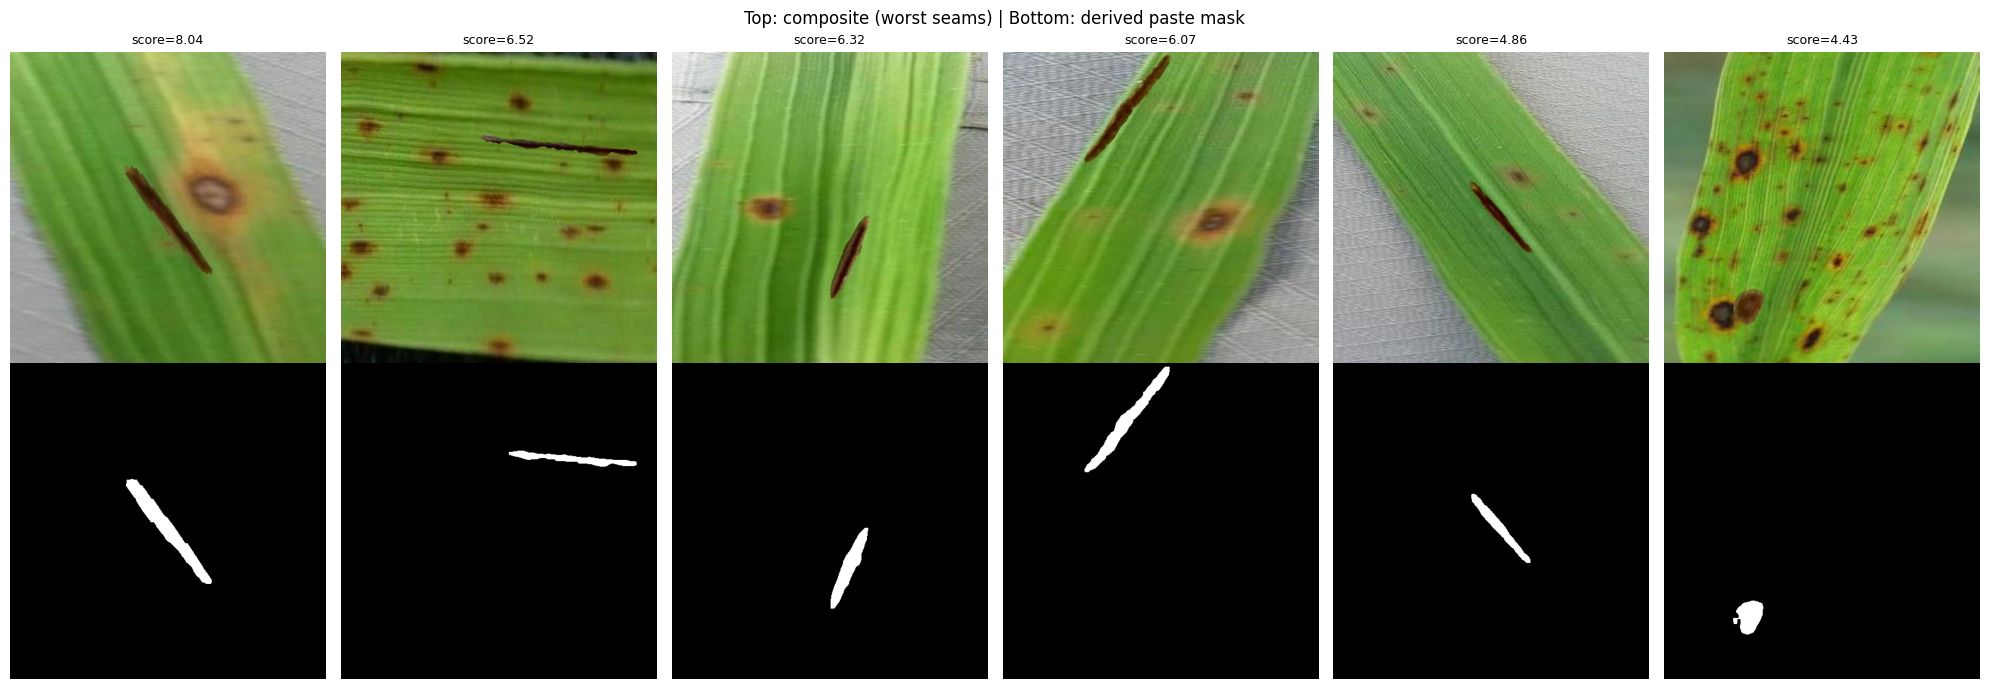

In [7]:
# ---- Visual check: worst offenders, showing derived mask alongside the composite ----
worst = valid.sort_values("boundary_artifact_score", ascending=False).head(6)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, (_, row) in enumerate(worst.iterrows()):
    syn_path = os.path.join(SYNTHETIC_DIR, row["filename"])
    match_row = df_match[df_match["synthetic_filename"] == row["filename"]].iloc[0]
    base_path = os.path.join(BROWN_SPOT_DIR, match_row["matched_base"])

    composite = cv2.imread(syn_path)
    base = cv2.imread(base_path)
    mask, _ = derive_paste_mask(composite, base)

    axes[0, i].imshow(cv2.cvtColor(composite, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"score={row['boundary_artifact_score']:.2f}", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].axis("off")

plt.suptitle("Top: composite (worst seams) | Bottom: derived paste mask")
plt.tight_layout()
plt.show()


## 4. No-Reference IQA (NIQE / BRISQUE)

Per-image naturalness score, no mask or matching needed — runs on the full
`blast_on_brown_spot_cleaned` folder directly.


In [8]:
import pyiqa

niqe_metric = pyiqa.create_metric('niqe', device=device)
brisque_metric = pyiqa.create_metric('brisque', device=device)

def load_as_tensor(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    tensor = torch.from_numpy(img).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    return tensor.to(device)

results_iqa = []
for fname in synthetic_files:
    path = os.path.join(SYNTHETIC_DIR, fname)
    try:
        t = load_as_tensor(path)
        niqe_score = float(niqe_metric(t).item())
        brisque_score = float(brisque_metric(t).item())
        results_iqa.append({"filename": fname, "niqe": round(niqe_score, 3),
                             "brisque": round(brisque_score, 3), "status": "ok"})
    except Exception as e:
        results_iqa.append({"filename": fname, "niqe": None, "brisque": None,
                             "status": f"error: {e}"})

df_iqa = pd.DataFrame(results_iqa)
df_iqa.to_csv(os.path.join(OUTPUT_DIR, "no_reference_iqa_scores.csv"), index=False)

valid_iqa = df_iqa[df_iqa["status"] == "ok"]
print(f"Scored {len(valid_iqa)}/{len(df_iqa)} images")
print(f"Mean NIQE:    {valid_iqa['niqe'].mean():.3f}  (lower = more natural)")
print(f"Mean BRISQUE: {valid_iqa['brisque'].mean():.3f}  (lower = more natural)")

df_iqa.sort_values("niqe", ascending=False, na_position="last").head(10)


Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/niqe_modelparameters.mat" to /root/.cache/torch/hub/pyiqa/niqe_modelparameters.mat



100%|██████████| 8.15k/8.15k [00:00<00:00, 30.2MB/s]


Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/brisque_svm_weights.pth" to /root/.cache/torch/hub/pyiqa/brisque_svm_weights.pth



100%|██████████| 112k/112k [00:00<00:00, 629kB/s]


Scored 617/618 images
Mean NIQE:    7.036  (lower = more natural)
Mean BRISQUE: 45.471  (lower = more natural)


,filename,niqe,brisque,status
597,blast_on_brownspot_brown_val (53).jpg,24.892,60.936,ok
520,blast_on_brownspot_brown_spot (42).jpg,24.358,55.581,ok
528,blast_on_brownspot_brown_spot (54).jpg,23.688,56.105,ok
515,blast_on_brownspot_brown_spot (37).jpg,21.962,49.211,ok
562,blast_on_brownspot_brown_spot (95).jpg,19.794,27.338,ok
501,blast_on_brownspot_brown_spot (32).jpg,19.092,55.116,ok
538,blast_on_brownspot_brown_spot (64).jpg,18.638,55.031,ok
385,blast_on_brownspot_brown_spot (124).jpg,16.696,75.814,ok
581,blast_on_brownspot_brown_val (28).jpg,16.657,83.689,ok
443,blast_on_brownspot_brown_spot (247).jpg,16.464,62.800,ok


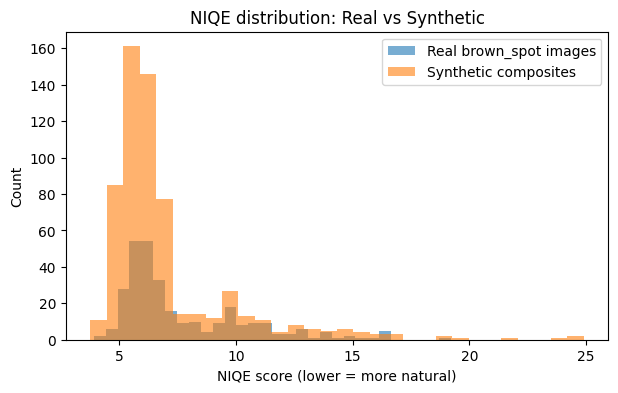

In [9]:
# Compare NIQE distribution: composites vs real brown_spot photos
def score_folder(folder, limit=300):
    scores = []
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))][:limit]
    for fname in files:
        try:
            t = load_as_tensor(os.path.join(folder, fname))
            scores.append(float(niqe_metric(t).item()))
        except Exception:
            continue
    return scores

real_scores = score_folder(BROWN_SPOT_DIR)
syn_scores = valid_iqa["niqe"].dropna().tolist()

plt.figure(figsize=(7, 4))
plt.hist(real_scores, bins=30, alpha=0.6, label="Real brown_spot images")
plt.hist(syn_scores, bins=30, alpha=0.6, label="Synthetic composites")
plt.xlabel("NIQE score (lower = more natural)")
plt.ylabel("Count")
plt.legend()
plt.title("NIQE distribution: Real vs Synthetic")
plt.show()


## 5. FID (Fréchet Inception Distance)

Compares the composite distribution against real `brown_spot` photos as the
reference distribution. Note: since there's no folder of *real* blast-on-brown-spot
multi-disease leaves (that's the whole reason you're generating synthetic ones),
this FID measures "do the composites still look like real rice-leaf photos
overall" rather than "do they match a real multi-disease distribution" — the
best available proxy for a paper/report table. If you get a real blast-only
image folder later, add it and I'll extend this to a per-class comparison.


In [10]:
from pytorch_fid import fid_score
import shutil
from PIL import Image

# ---- Pre-resize both folders to a consistent size for FID ----
# (brown_spot has mixed resolutions e.g. 512x512 and 1600x1600 - pytorch-fid's
# dataloader can't batch different-sized tensors together without this step)
FID_TMP_DIR = "/content/fid_tmp"
FID_REAL_DIR = os.path.join(FID_TMP_DIR, "real")
FID_SYN_DIR = os.path.join(FID_TMP_DIR, "synthetic")

shutil.rmtree(FID_TMP_DIR, ignore_errors=True)
os.makedirs(FID_REAL_DIR, exist_ok=True)
os.makedirs(FID_SYN_DIR, exist_ok=True)

FID_IMG_SIZE = 299  # Inception's native input size

def resize_and_copy(src_dir, dst_dir, size=FID_IMG_SIZE):
    count = 0
    for fname in os.listdir(src_dir):
        src_path = os.path.join(src_dir, fname)
        if not os.path.isfile(src_path):
            continue
        try:
            img = Image.open(src_path).convert("RGB")
            img = img.resize((size, size), Image.BICUBIC)
            out_name = os.path.splitext(fname)[0] + ".png"
            img.save(os.path.join(dst_dir, out_name))
            count += 1
        except Exception as e:
            print(f"  skipped {fname}: {e}")
    return count

n_real = resize_and_copy(BROWN_SPOT_DIR, FID_REAL_DIR)
n_syn = resize_and_copy(SYNTHETIC_DIR, FID_SYN_DIR)
print(f"Resized {n_real} real images and {n_syn} synthetic images to {FID_IMG_SIZE}x{FID_IMG_SIZE}")

batch_size = min(50, n_real, n_syn)  # avoid batch_size > sample count errors

fid_value = fid_score.calculate_fid_given_paths(
    [FID_REAL_DIR, FID_SYN_DIR],
    batch_size=batch_size,
    device=device,
    dims=2048
)
print(f"FID (real brown_spot vs synthetic composites): {fid_value:.3f}  (lower = closer to real distribution)")

with open(os.path.join(OUTPUT_DIR, "fid_score.txt"), "w") as f:
    f.write(f"FID (real brown_spot vs synthetic composites): {fid_value:.4f}\n")


Resized 1389 real images and 618 synthetic images to 299x299
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:01<00:00, 48.1MB/s]
100%|██████████| 13/13 [00:03<00:00,  3.70it/s]


FID (real brown_spot vs synthetic composites): 47.756  (lower = closer to real distribution)


## 6. Real-vs-Fake Discriminator

Trains a small CNN to separate real `brown_spot` images from synthetic
composites. Accuracy near 50% = composites are realistic; near 100% = the model
easily spots them (check the confusion matrix to see which class it's better at
catching).


In [11]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

IMG_SIZE = 128
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class RealFakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.paths, self.labels = [], []
        for fname in os.listdir(real_dir):
            p = os.path.join(real_dir, fname)
            if os.path.isfile(p):
                self.paths.append(p); self.labels.append(0)
        for fname in os.listdir(fake_dir):
            p = os.path.join(fake_dir, fname)
            if os.path.isfile(p):
                self.paths.append(p); self.labels.append(1)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

dataset = RealFakeDataset(BROWN_SPOT_DIR, SYNTHETIC_DIR, transform=transform)
n_val = int(0.2 * len(dataset))
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
print(f"Dataset: {len(dataset)} total | train {n_train} | val {n_val}")


Dataset: 2007 total | train 1606 | val 401


In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total if total > 0 else 0
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={total_loss/len(train_loader):.4f} | val_acc={val_acc:.3f}")

print("\nval_acc near 0.5 -> composites look realistic. val_acc near 1.0 -> inspect confusion matrix below.")


Epoch 1/10 | train_loss=0.6120 | val_acc=0.681
Epoch 2/10 | train_loss=0.6038 | val_acc=0.681
Epoch 3/10 | train_loss=0.5741 | val_acc=0.681
Epoch 4/10 | train_loss=0.5765 | val_acc=0.681
Epoch 5/10 | train_loss=0.5740 | val_acc=0.681
Epoch 6/10 | train_loss=0.5726 | val_acc=0.681
Epoch 7/10 | train_loss=0.5666 | val_acc=0.681
Epoch 8/10 | train_loss=0.5711 | val_acc=0.681
Epoch 9/10 | train_loss=0.5689 | val_acc=0.681
Epoch 10/10 | train_loss=0.5845 | val_acc=0.681

val_acc near 0.5 -> composites look realistic. val_acc near 1.0 -> inspect confusion matrix below.


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(device)).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix (rows=true, cols=pred) [0=real brown_spot, 1=synthetic]:")
print(cm)
print()
print(classification_report(all_labels, all_preds, target_names=["real", "synthetic"]))


Confusion matrix (rows=true, cols=pred) [0=real brown_spot, 1=synthetic]:
[[273   0]
 [128   0]]

              precision    recall  f1-score   support

        real       0.68      1.00      0.81       273
   synthetic       0.00      0.00      0.00       128

    accuracy                           0.68       401
   macro avg       0.34      0.50      0.41       401
weighted avg       0.46      0.68      0.55       401



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 7. Combined Summary


In [14]:
summary = df_boundary.merge(df_iqa, on="filename", how="outer", suffixes=("_boundary", "_iqa"))
summary.to_csv(os.path.join(OUTPUT_DIR, "realness_validation_summary.csv"), index=False)

print("Saved per-image summary to:", os.path.join(OUTPUT_DIR, "realness_validation_summary.csv"))
print()
print("=== Dataset-level realness report ===")
try:
    print(f"FID (real vs synthetic): {fid_value:.3f}")
except NameError:
    print("FID not computed in this run.")
try:
    print(f"Discriminator val accuracy: {val_acc:.3f} (0.5 = ideal/realistic, 1.0 = easily detected as fake)")
except NameError:
    print("Discriminator not trained in this run.")

summary.head(10)


Saved per-image summary to: /content/drive/MyDrive/realness_validation/realness_validation_summary.csv

=== Dataset-level realness report ===
FID (real vs synthetic): 47.756
Discriminator val accuracy: 0.681 (0.5 = ideal/realistic, 1.0 = easily detected as fake)


,filename,status_boundary,grad_ratio,lap_ratio,color_jump_lab,boundary_artifact_score,flag_visible_seam,niqe,brisque,status_iqa
0,blast_on_brownspot_BROWNSPOT1_092.jpg,ok,2.9193,1.5025,42.7305,2.6233,False,7.167,34.327,ok
1,blast_on_brownspot_BROWNSPOT3_036.jpg,ok,3.7592,2.6303,38.1396,3.3186,False,5.990,51.041,ok
2,blast_on_brownspot_BROWNSPOT3_068.jpg,ok,2.9249,2.1511,43.4219,2.8988,False,6.762,55.823,ok
3,blast_on_brownspot_BROWNSPOT3_095.jpg,ok,2.8455,3.0076,44.8083,3.2374,False,5.853,38.586,ok
4,blast_on_brownspot_BROWNSPOT4_020.jpg,ok,3.5871,4.7781,36.7235,4.0805,False,6.297,40.779,ok
5,blast_on_brownspot_BROWNSPOT4_057.jpg,ok,1.6814,5.1350,35.8961,3.4445,False,6.723,33.062,ok
6,blast_on_brownspot_BROWNSPOT4_058.jpg,ok,3.0591,2.0350,22.7916,2.4934,False,5.351,65.184,ok
7,blast_on_brownspot_BROWNSPOT4_075.jpg,ok,4.3377,3.7072,33.3639,3.8853,False,6.412,40.144,ok
8,blast_on_brownspot_BROWNSPOT4_095.jpg,ok,2.2572,7.0912,34.4408,4.4282,False,6.668,78.525,ok
9,blast_on_brownspot_BROWNSPOT4_167.jpg,mask_derivation_failed,NaN,NaN,NaN,NaN,NaN,6.062,42.794,ok
